In [63]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.optimize import curve_fit

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [192]:
# main = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
main = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))
main['EFFTIME_ELG'] = 8.60 * main['TSNR2_ELG']
main['EFFTIME_LRG'] = 12.15 * main['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = main['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove "no data" fibers
mask = main['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Apply LRG mask
mask = main['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove QSO targets
mask = main['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# mask = main['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# main = main[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = main['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# main = main[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(main['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# main = main[~mask_bad]
# print(len(main), len(np.unique(main['TARGETID'])))

main['zfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_Z']) - 1.211 * main['EBV']

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046


In [193]:
mask = main['zfibermag']>21.6
np.sum(mask)/len(mask)

0.0038446263670616977

In [197]:
main['zfibermag'].max()

21.61

In [205]:
np.sum(main['PHOTSYS']=='N')/len(main)

0.30533074800009347

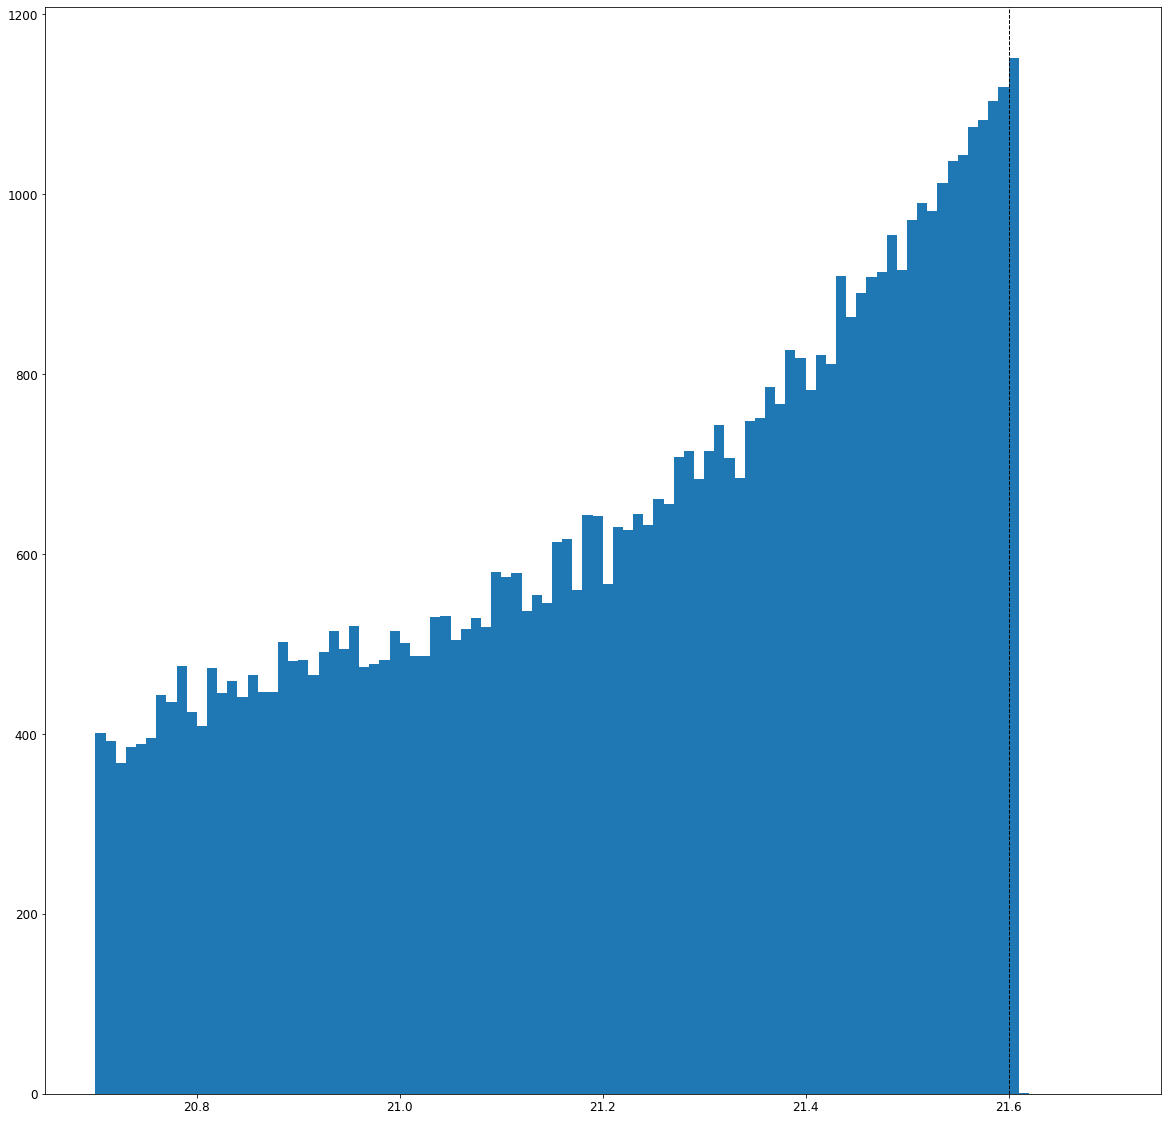

In [204]:
plt.figure(figsize=(20, 20))
plt.hist(main['zfibermag'][main['PHOTSYS']=='N'], 100, range=(20.7, 21.7))
plt.axvline(21.6, lw=1, ls='--', color='k')
plt.show()

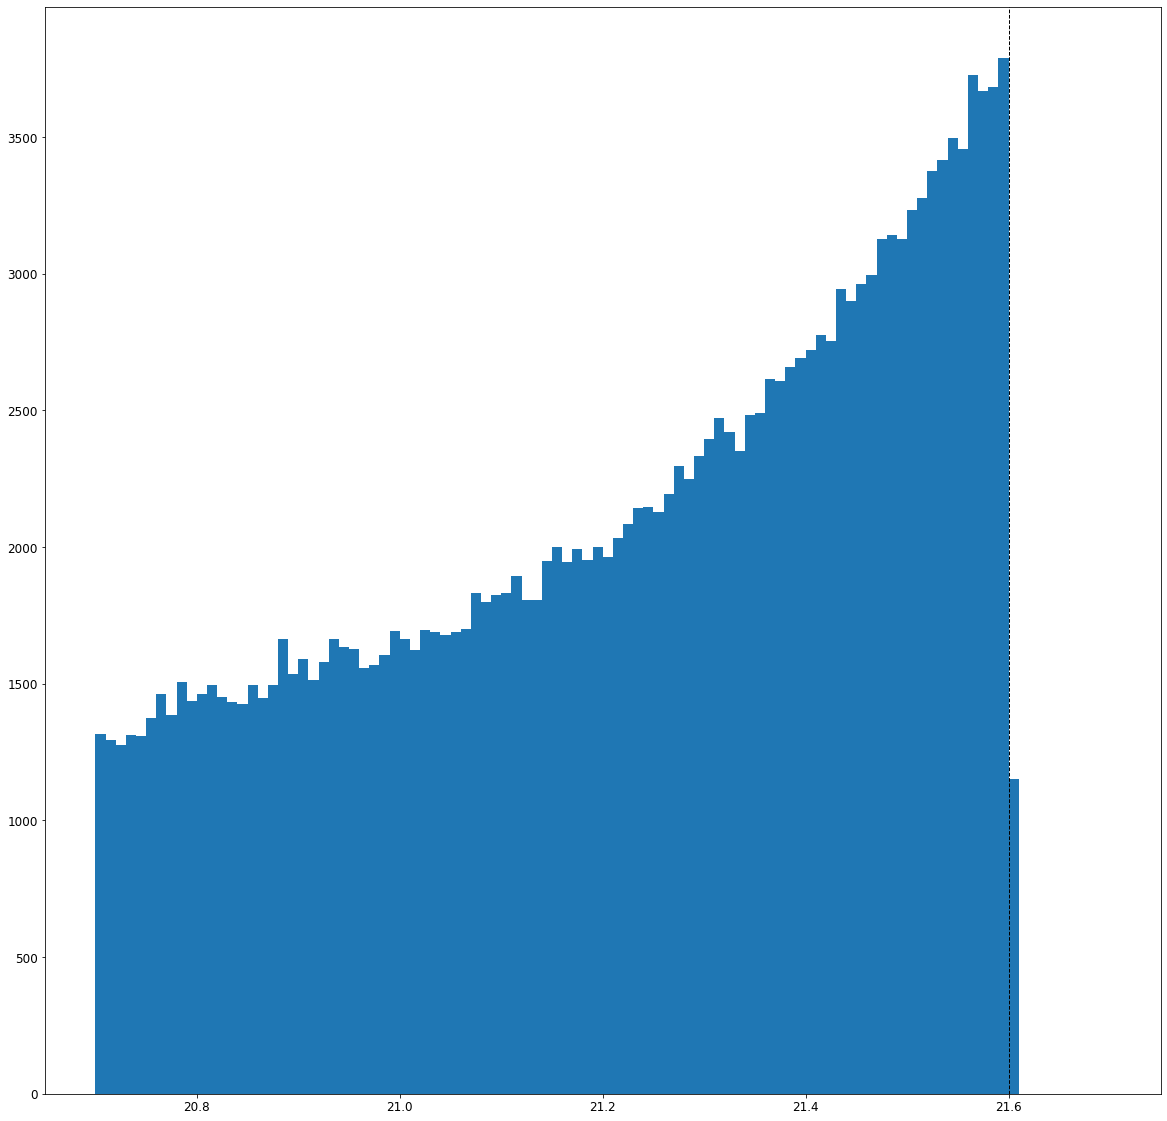

In [203]:
plt.figure(figsize=(20, 20))
plt.hist(main['zfibermag'], 100, range=(20.7, 21.7))
plt.axvline(21.6, lw=1, ls='--', color='k')
plt.show()

In [4]:
# mask_quality_main = main['ZWARN']==0
# mask_quality_main &= main['Z']<1.4
# mask_quality_main &= main['DELTACHI2']>15

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*main['Z']))
mask_quality_main = ((main['DELTACHI2']>d) & (main['DELTACHI2']>10)) | (main['DELTACHI2']>30)
mask_quality_main &= main['Z']<1.4
mask_quality_main &= main['ZWARN']<1.4

print('Main LRGs in Main Survey:')
print('Rejection rate (all): {:.1f}% ({}/{})'.format(100*np.sum((~mask_quality_main))/len(mask_quality_main), np.sum((~mask_quality_main)), len(mask_quality_main)))
mask = main['EFFTIME_LRG']>800
print('Rejection rate (EFFTIME>800s): {:.1f}% ({}/{})'.format(100*np.sum((~mask_quality_main) & mask)/np.sum(mask), np.sum((~mask_quality_main) & mask), np.sum(mask)))

Main LRGs in Main Survey:
Rejection rate (all): 1.2% (3605/299639)
Rejection rate (EFFTIME>800s): 1.1% (3251/288287)


In [6]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

## Failures rates vs EFFTIME

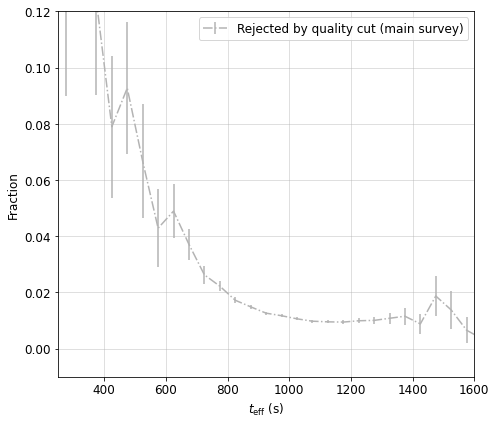

In [88]:
bin_edges = np.linspace(0, 2000, 41)
bin_center_main, bin_reject_rate_main, bin_reject_rate_err_main = binned_frac(main['EFFTIME_LRG'], (~mask_quality_main), bin_edges, minsize=10, error_floor=False)

plt.figure(figsize=(7., 6.))
plt.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (main survey)', color='0.7')
# plt.xlabel('EFFTIME_LRG')
plt.xlabel('$t_\mathrm{eff}$ (s)')
plt.ylabel('Fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
# plt.title('Main LRGs')
plt.axis([250, 1600, -0.01, 0.12])
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_vs_efftime.pdf')
plt.show()

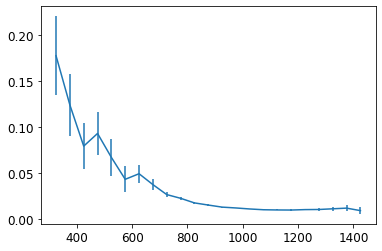

In [89]:
xdata = bin_center_main[6:-11].copy()
ydata = bin_reject_rate_main[6:-11].copy()
yerr = bin_reject_rate_err_main[6:-11].copy()
mask = np.isfinite(ydata) & (yerr!=0)
xdata = xdata[mask]
ydata = ydata[mask]
yerr = yerr[mask]

plt.errorbar(xdata, ydata, yerr=yerr)
plt.show()

[5.724642620082749e-17, 176.70575992433308, 0.007821966465134614]
0.011306922182688467


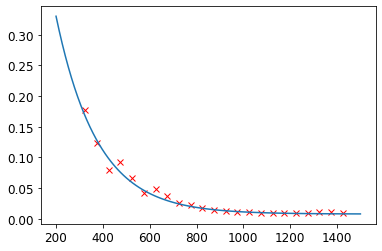

In [90]:
def failure_rate_vs_efftime(x, a, b, c):
    return np.clip(np.exp(-(x+a)/b)+c, 0, 1)
#     return np.clip(np.exp(-(x+120)/250)+0.015)

popt_efftime, _ = curve_fit(failure_rate_vs_efftime, xdata, ydata, sigma=yerr, p0=[120, 250, 0.01], bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
print(list(popt_efftime))
popt_efftime = [0, 176.7, 0.007822]
print(failure_rate_vs_efftime(1000., *popt_efftime))

x = np.linspace(200, 1500, 100)
y = failure_rate_vs_efftime(x, *popt_efftime)

plt.plot(xdata, ydata, 'rx')
plt.plot(x, y)
plt.show()

In [91]:
mask_nominal_main = (main['EFFTIME_LRG']>800.) & (main['EFFTIME_LRG']<1200.)
print('Nominal depth (main)', np.sum(mask_nominal_main), np.sum(~mask_nominal_main), np.sum(mask_nominal_main)/len(mask_nominal_main))

Nominal depth (main) 260710 38929 0.8700803299970965


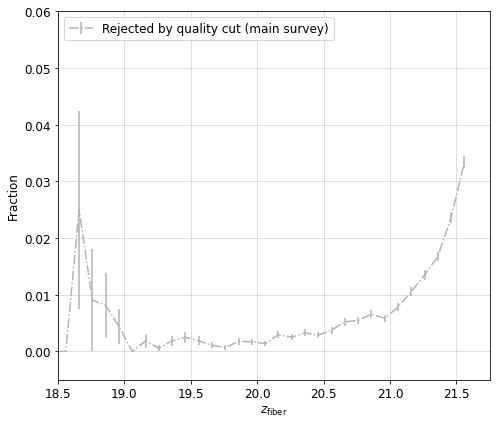

In [92]:
area = len(main)/600

bin_edges = np.linspace(18.01, 22.01, 41)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

mask = mask_nominal_main.copy()
bin_center_main, bin_reject_rate_main, bin_reject_rate_err_main = binned_frac(main['zfibermag'][mask], (~mask_quality_main)[mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (main survey)', color='0.7')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Fraction')
ax1.grid(alpha=0.5)
ax1.legend(loc='upper left')
# ax1.title('Main LRGs')
ax1.axis([18.5, 21.75, -0.005, 0.06])
ax1.set_zorder(1)
ax1.patch.set_visible(False)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_vs_zfiber.pdf')
plt.show()

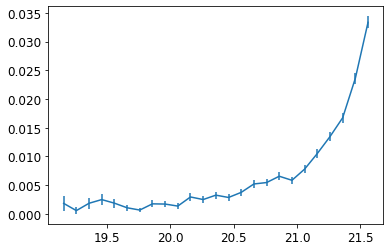

In [112]:
xdata = bin_center_main[10:].copy()
ydata = bin_reject_rate_main[10:].copy()
yerr = bin_reject_rate_err_main[10:].copy()
mask = np.isfinite(ydata) & (yerr!=0)
xdata = xdata[mask]
ydata = ydata[mask]
yerr = yerr[mask]

plt.errorbar(xdata, ydata, yerr=yerr)
plt.show()

[3.001151484442585, -17.931001213369356, 5.653602691048074e-07, 0.0015434827551957817]
0.03571594923617446


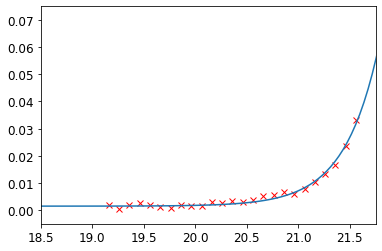

In [114]:
def failure_rate_vs_zfiber(x, a, b, c, d):
    return np.clip(np.exp(a*(x + b)) * c + d, 0, 1)

popt_zfiber, _ = curve_fit(failure_rate_vs_zfiber, xdata, ydata, sigma=yerr, p0=[3., -18., 1e-7, 1e-3], bounds=([3, -np.inf, -np.inf, 0], [5, np.inf, np.inf, np.inf]))
print(list(popt_zfiber))
popt_zfiber = [3.001, -17.931, 5.654e-07, 0.0015]
print(failure_rate_vs_zfiber(21.6, *popt_zfiber))

x = np.linspace(18, 22, 100)
y = failure_rate_vs_zfiber(x, *popt_zfiber)

plt.plot(xdata, ydata, 'rx')
plt.axis([18.5, 21.75, -0.005, 0.075])
plt.plot(x, y)
plt.show()

## Success rates in 2D

In [120]:
# Include Main LRGs from SV
# all_lrg = vstack([cat[cat['main_lrg']], main], join_type='inner')
all_lrg = main.copy()
all_lrg['success_prob'] = 1 - failure_rate_vs_efftime(all_lrg['EFFTIME_LRG'], *popt_efftime)
all_lrg['success_prob'] *= 1 - failure_rate_vs_zfiber(all_lrg['zfibermag'], *popt_zfiber)

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*all_lrg['Z']))
mask_remove = (d>30) & (all_lrg['DELTACHI2']<30)
mask_remove |= (d<30) & (all_lrg['DELTACHI2']<d)
mask_remove |= (all_lrg['DELTACHI2']<10)
mask_quality_all_lrg = all_lrg['ZWARN']==0
mask_quality_all_lrg &= all_lrg['Z']<1.4
mask_quality_all_lrg &= (~mask_remove)

print('Rejection rate (all): {:.1f}% ({}/{})'.format(100*np.sum((~mask_quality_all_lrg))/len(mask_quality_all_lrg), np.sum((~mask_quality_all_lrg)), len(mask_quality_all_lrg)))
mask = all_lrg['EFFTIME_LRG']>800
print('Rejection rate (EFFTIME>800s): {:.1f}% ({}/{})'.format(100*np.sum((~mask_quality_all_lrg) & mask)/np.sum(mask), np.sum((~mask_quality_all_lrg) & mask), np.sum(mask)))

Rejection rate (all): 1.2% (3605/299639)
Rejection rate (EFFTIME>800s): 1.1% (3251/288287)


<ipython-input-162-00c736295f17>:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


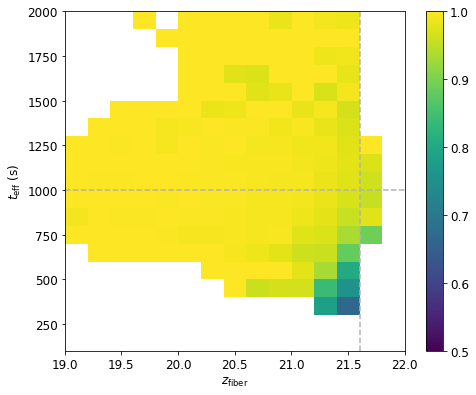

In [162]:
zfiber_bin_edges = np.linspace(18.0, 22.0, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(all_lrg['zfibermag'], all_lrg['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = mask_quality_all_lrg.copy()
count_2d_good = np.histogram2d(all_lrg['zfibermag'][mask], all_lrg['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

<ipython-input-165-ed53cdd0e9d2>:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


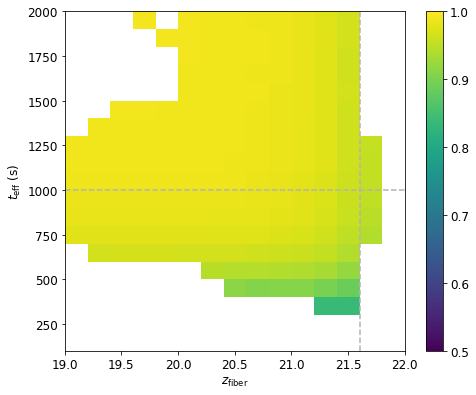

In [165]:
zfiber_bin_edges = np.linspace(18.0, 22.0, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(all_lrg['zfibermag'], all_lrg['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = mask_quality_all_lrg.copy()
count_2d_good_predict = np.histogram2d(all_lrg['zfibermag'], all_lrg['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=all_lrg['success_prob'])[0]
success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

__Add SV1 LRGs from deep coadds__

In [170]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_perexp_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_perexp_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# mask = cat['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

FIBERSTATUS 464751 107007 0.18715435551404616
No data 464751 0 0.0
LRG mask 417693 47058 0.10125422000167832
Remove QSO targets 403772 13921 0.03332830571735701


In [171]:
# cat_1x = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_1x_depth_lrg.fits'))
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))
cat_1x['EFFTIME_ELG'] = 8.60 * cat_1x['TSNR2_ELG']
cat_1x['EFFTIME_LRG'] = 12.15 * cat_1x['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# mask = cat_1x['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat_1x['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat_1x['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat_1x = cat_1x[~mask_bad]
# print(len(cat_1x), len(np.unique(cat_1x['TARGETID'])))

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
LRG mask 25008 2102 0.07753596458871265
Remove QSO targets 24493 515 0.020593410108765194


In [172]:
columns = list(np.intersect1d(cat.colnames, cat_1x.colnames))
cat = cat[columns]
cat_1x = cat_1x[columns]

cat = vstack([cat, cat_1x])

In [173]:
# deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(deep['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# deep = deep[~mask_bad]
# print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

deep_all = deep.copy()

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove QSO targets 39668 1672 0.040445089501693274
39533 39533


In [176]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
main['zfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_Z']) - 1.211 * main['EBV']
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

In [183]:
all_lrg = vstack([cat[cat['main_lrg']], main], join_type='inner')

In [184]:
mask1 = all_lrg['zfibermag']<=21.6
mask2 = deep_all['zfibermag']>21.6
mask3 = cat['zfibermag']>21.6
lrg1 = vstack([all_lrg[mask1], deep_all[mask2], cat[mask3]], join_type='inner')
# lrg1 = vstack([cat, main], join_type='inner')

In [185]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*lrg1['Z']))
mask_remove = (d>30) & (lrg1['DELTACHI2']<30)
mask_remove |= (d<30) & (lrg1['DELTACHI2']<d)
mask_remove |= (lrg1['DELTACHI2']<10)
mask_quality_lrg1 = lrg1['ZWARN']==0
mask_quality_lrg1 &= lrg1['Z']<1.4
mask_quality_lrg1 &= (~mask_remove)

print('Rejection rate (all): {:.1f}% ({}/{})'.format(100*np.sum((~mask_quality_lrg1))/len(mask_quality_lrg1), np.sum((~mask_quality_lrg1)), len(mask_quality_lrg1)))
mask = lrg1['EFFTIME_LRG']>3000
print('Rejection rate (EFFTIME>300s): {:.1f}% ({}/{})'.format(100*np.sum((~mask_quality_lrg1) & mask)/np.sum(mask), np.sum((~mask_quality_lrg1) & mask), np.sum(mask)))

Rejection rate (all): 17.7% (102084/578083)
Rejection rate (EFFTIME>300s): 1.3% (139/10484)


<ipython-input-189-aa032696d552>:19: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


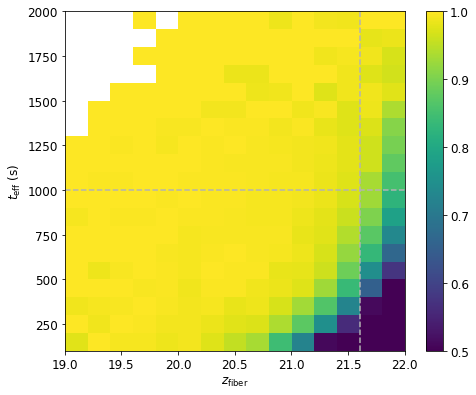

In [189]:
zfiber_bin_edges = np.linspace(18., 22., 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

zfiber_index = np.digitize(lrg1['zfibermag'], zfiber_bin_edges)
efftime_index = np.digitize(lrg1['EFFTIME_LRG'], efftime_bin_edges)
tmp, count = np.unique([zfiber_index, efftime_index], axis=1, return_counts=True)
count_2d_all = np.zeros((len(zfiber_bin_edges)+1, len(efftime_bin_edges)+1))
count_2d_all[tmp[0], tmp[1]] = count.copy()
count_2d_all = count_2d_all[1:-1, 1:-1]

mask = mask_quality_lrg1.copy()
zfiber_index = np.digitize(lrg1['zfibermag'][mask], zfiber_bin_edges)
efftime_index = np.digitize(lrg1['EFFTIME_LRG'][mask], efftime_bin_edges)
tmp, count = np.unique([zfiber_index, efftime_index], axis=1, return_counts=True)
count_2d_good = np.zeros((len(zfiber_bin_edges)+1, len(efftime_bin_edges)+1))
count_2d_good[tmp[0], tmp[1]] = count.copy()
count_2d_good = count_2d_good[1:-1, 1:-1]

success_2d = count_2d_good/count_2d_all
success_2d[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/failure_rate_in_2d.pdf')
plt.show()

In [190]:
# Include Main LRGs from SV
# lrg1 = vstack([cat[cat['main_lrg']], main], join_type='inner')
lrg1['success_prob'] = 1 - failure_rate_vs_efftime(lrg1['EFFTIME_LRG'], *popt_efftime)
lrg1['success_prob'] *= 1 - failure_rate_vs_zfiber(lrg1['zfibermag'], *popt_zfiber)

<ipython-input-191-939a44243059>:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


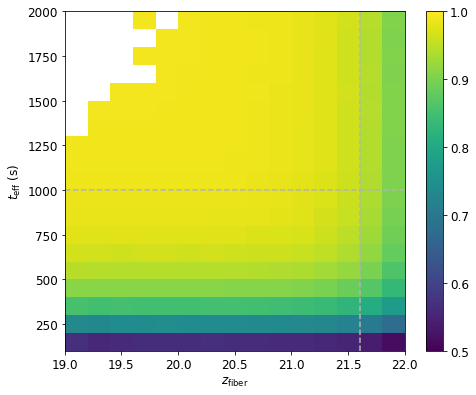

In [191]:
zfiber_bin_edges = np.linspace(18.0, 22.0, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(lrg1['zfibermag'], lrg1['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = mask_quality_lrg1.copy()
count_2d_good_predict = np.histogram2d(lrg1['zfibermag'], lrg1['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=lrg1['success_prob'])[0]
success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()